In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Load and merge datasets (same as BPN)
ppg = pd.read_csv('data_nba/Player Per Game.csv')
allstar = pd.read_csv('data_nba/All-Star Selections.csv')

ppg = ppg[ppg['lg'] == 'NBA'].copy()
allstar = allstar[allstar['lg'] == 'NBA'][['player_id', 'season']].drop_duplicates()
allstar['all_star'] = 1

df = ppg.merge(allstar, on=['player_id', 'season'], how='left')
df['all_star'] = df['all_star'].fillna(0).astype(int)

features = [
    'pts_per_game', 'trb_per_game', 'ast_per_game',
    'stl_per_game', 'blk_per_game', 'mp_per_game',
    'fg_percent', 'ft_percent', 'g', 'gs'
]
target = 'all_star'

df = df[['player', target] + features].reset_index(drop=True)
# como no tengo ciertos datos, estimo con la mediana
imputer = SimpleImputer(strategy='median')
df[features] = imputer.fit_transform(df[features])

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'All-Stars in test: {y_test.sum()}')

Train: (24895, 10) | Test: (6224, 10)
All-Stars in test: 384


In [17]:
# Test different depths
depths = [3, 5, 10, 15, None]
results_depth = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    results_depth.append({'Max Depth': str(d), 'Accuracy (%)': round(acc * 100, 2)})
    print(f'Depth {str(d):5} → Accuracy: {acc:.4f}')

df_depth = pd.DataFrame(results_depth)
print('\n', df_depth)

Depth 3     → Accuracy: 0.9555
Depth 5     → Accuracy: 0.9592
Depth 10    → Accuracy: 0.9581
Depth 15    → Accuracy: 0.9537
Depth None  → Accuracy: 0.9507

   Max Depth  Accuracy (%)
0         3         95.55
1         5         95.92
2        10         95.81
3        15         95.37
4      None         95.07


Criterion gini     → Accuracy: 0.9026
Criterion entropy  → Accuracy: 0.9103

   Criterion  Accuracy (%)
0      Gini         90.26
1   Entropy         91.03


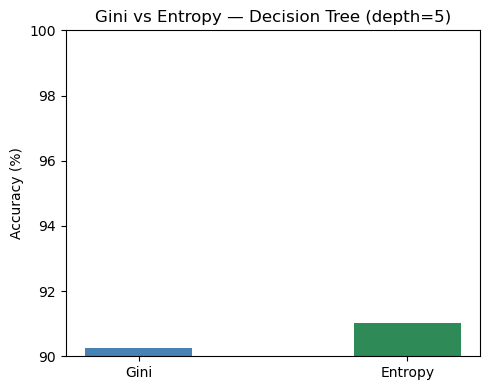

In [18]:
# Gini vs Entropy — criterion comparison (both at best depth=5, balanced)
criteria = ['gini', 'entropy']
results_criterion = []

for crit in criteria:
    dt = DecisionTreeClassifier(max_depth=5, criterion=crit, class_weight='balanced', random_state=42)
    dt.fit(X_train, y_train)
    y_c = dt.predict(X_test)
    acc = accuracy_score(y_test, y_c)
    results_criterion.append({'Criterion': crit.capitalize(), 'Accuracy (%)': round(acc * 100, 2)})
    print(f'Criterion {crit:8} → Accuracy: {acc:.4f}')

df_criterion = pd.DataFrame(results_criterion)
print('\n', df_criterion)

plt.figure(figsize=(5, 4))
plt.bar(df_criterion['Criterion'], df_criterion['Accuracy (%)'], color=['steelblue', 'seagreen'], width=0.4)
plt.title('Gini vs Entropy — Decision Tree (depth=5)')
plt.ylabel('Accuracy (%)')
plt.ylim(90, 100)
plt.tight_layout()
plt.show()

In [ ]:
import unicodedata
# Best model + Classification Report
best_dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
best_dt.fit(X_train, y_train)
y_pred = best_dt.predict(X_test)

print("Classification Report ")
print(classification_report(y_test, y_pred, target_names=['Non All-Star', 'All-Star']))
def _norm(s):
    return unicodedata.normalize('NFD', s).encode('ascii', 'ignore').decode().lower()

THRESHOLD = 0.35
famous = ['LeBron James', 'Stephen Curry', 'Kevin Durant',
          'Giannis Antetokounmpo', 'Nikola Jokic']

print(f'\n{"Player":<28} {"P(All-Star)":<14} {"Predicted":<15} {"Actual"}')
print('-' * 68)
for name in famous:
    mask = df['player'].apply(_norm).str.contains(_norm(name), regex=False)
    rows = df[mask]
    if rows.empty:
        print(f'{name:<28} not found in dataset')
        continue
    # prefer a season where player WAS an All-Star
    allstar_rows = rows[rows['all_star'] == 1]
    row = allstar_rows.iloc[-1] if not allstar_rows.empty else rows.iloc[-1]
    x    = scaler.transform([row[features].values])
    prob = best_dt.predict_proba(x)[0][1]
    pred = 1 if prob >= THRESHOLD else 0
    actual = int(row['all_star'])
    print(f'{row["player"]:<28} {prob:<14.3f} '
          f'{"All-Star" if pred==1 else "Non All-Star":<15} '
          f'{"All-Star" if actual==1 else "Non All-Star"}')

Classification Report 
              precision    recall  f1-score   support

Non All-Star       0.99      0.90      0.95      5840
    All-Star       0.38      0.92      0.54       384

    accuracy                           0.90      6224
   macro avg       0.69      0.91      0.74      6224
weighted avg       0.96      0.90      0.92      6224


Player                       P(All-Star)    Predicted       Actual
--------------------------------------------------------------------
LeBron James                 0.991          All-Star        All-Star
Stephen Curry                0.991          All-Star        All-Star
Kevin Durant                 0.991          All-Star        All-Star
Giannis Antetokounmpo        0.955          All-Star        All-Star
Nikola Jokić                 0.955          All-Star        All-Star


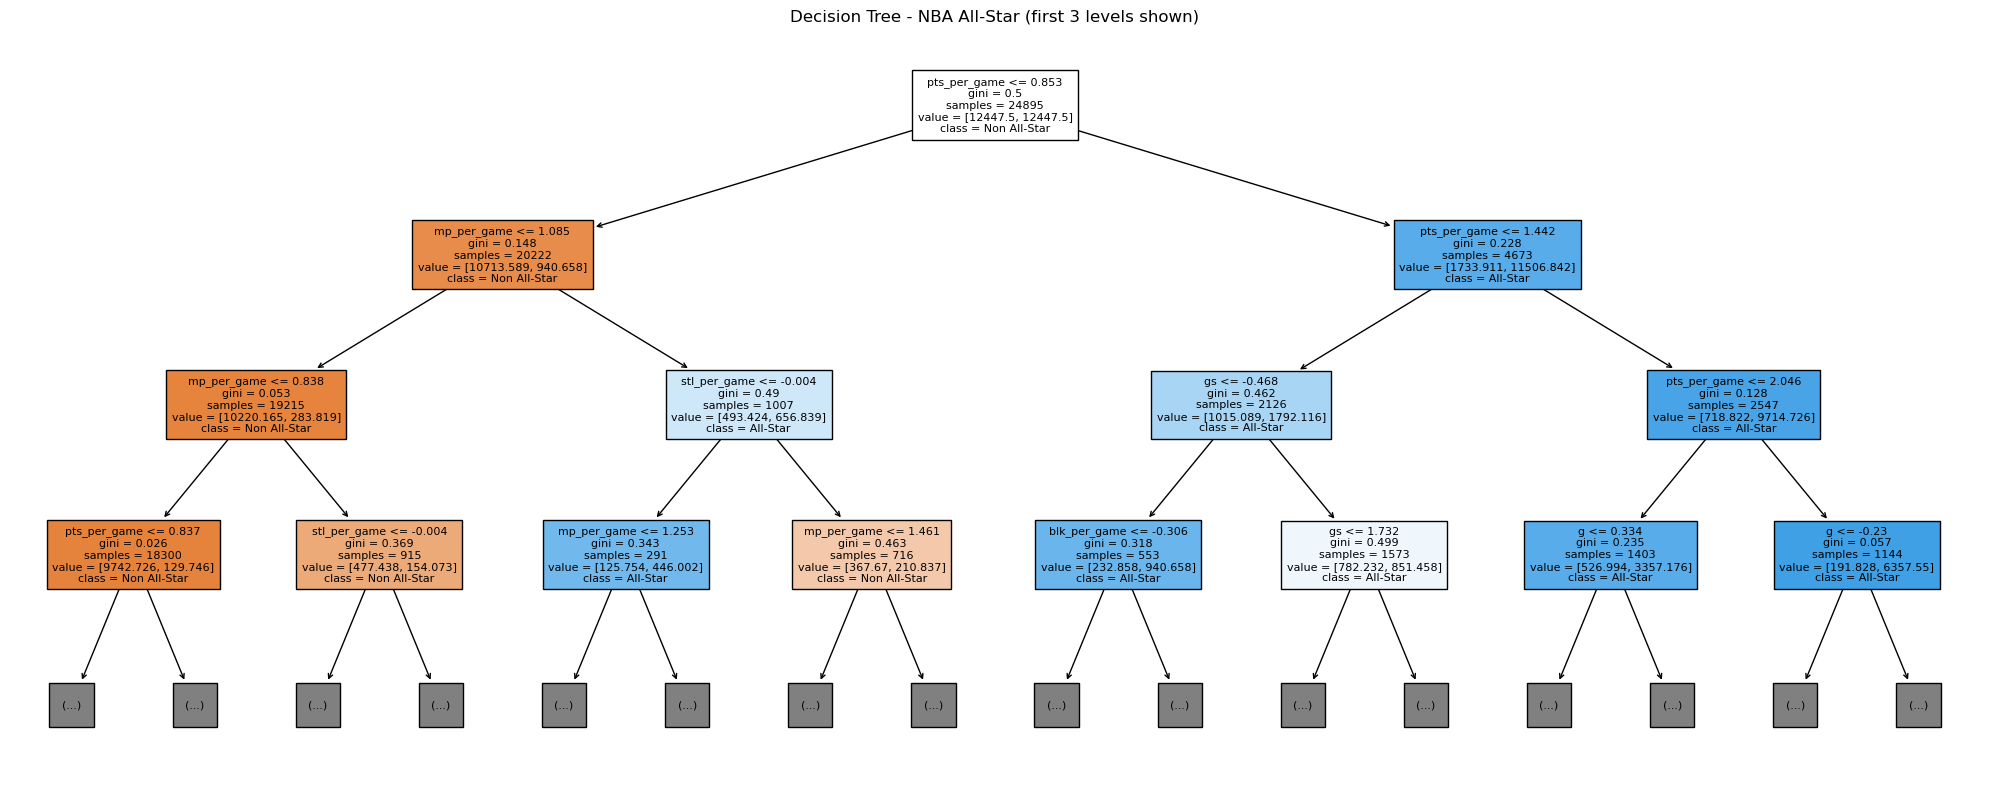

In [20]:
# Visualize the tree
plt.figure(figsize=(20, 8))
plot_tree(best_dt, feature_names=features,
          class_names=['Non All-Star', 'All-Star'],
          filled=True, max_depth=3, fontsize=8)
plt.title('Decision Tree - NBA All-Star (first 3 levels shown)')
plt.tight_layout()
plt.show()

                               Model  Accuracy (%)
0            BPN (LR=0.01, balanced)         96.45
1  Decision Tree (depth=5, balanced)         90.26


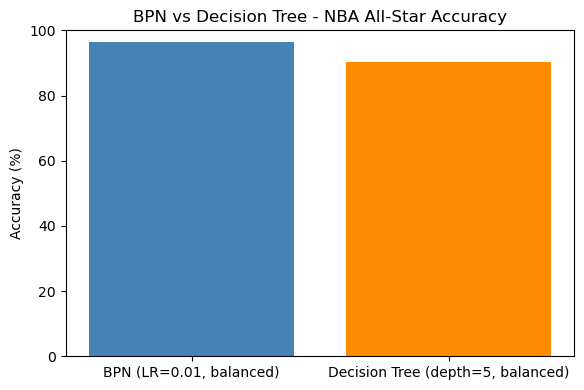

In [21]:
# BPN vs Decision Tree comparison
# NOTE: update bpn_acc after running bpn_nba.ipynb Cell 9 (best model with oversampling)
bpn_acc = 0.9645  # placeholder — replace with actual accuracy from bpn_nba.ipynb Cell 9
dt_acc = accuracy_score(y_test, y_pred)

comparison = pd.DataFrame({
    'Model': ['BPN (LR=0.01, balanced)', 'Decision Tree (depth=5, balanced)'],
    'Accuracy (%)': [round(bpn_acc * 100, 2), round(dt_acc * 100, 2)]
})
print(comparison)

plt.figure(figsize=(6, 4))
plt.bar(comparison['Model'], comparison['Accuracy (%)'], color=['steelblue', 'darkorange'])
plt.title('BPN vs Decision Tree - NBA All-Star Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()